/tmp/ipython-input-2984395484.py:35: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  sr = sqrtm(rho)
/tmp/ipython-input-2984395484.py:38: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  root = sqrtm(inner)
/tmp/ipython-input-2984395484.py:35: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  sr = sqrtm(rho)
/tmp/ipython-input-2984395484.py:38: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  root = sqrtm(inner)



=== Full DataFrame dfL ===


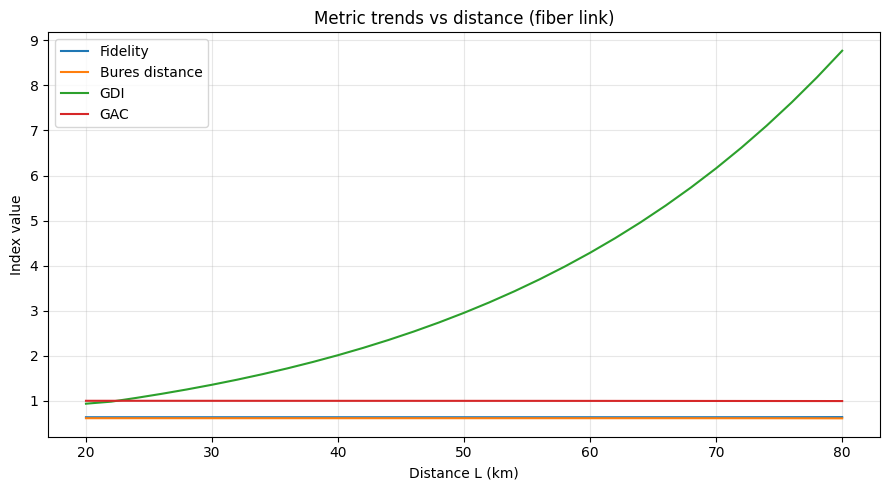

/tmp/ipython-input-2984395484.py:35: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  sr = sqrtm(rho)
/tmp/ipython-input-2984395484.py:38: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  root = sqrtm(inner)


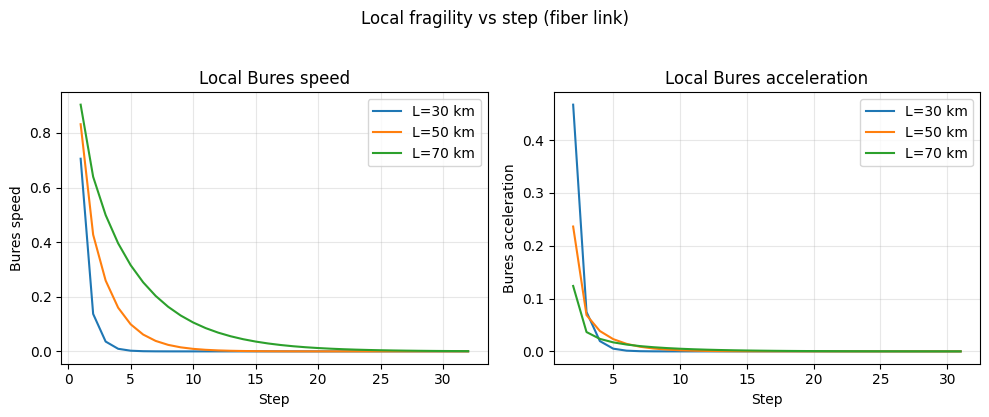

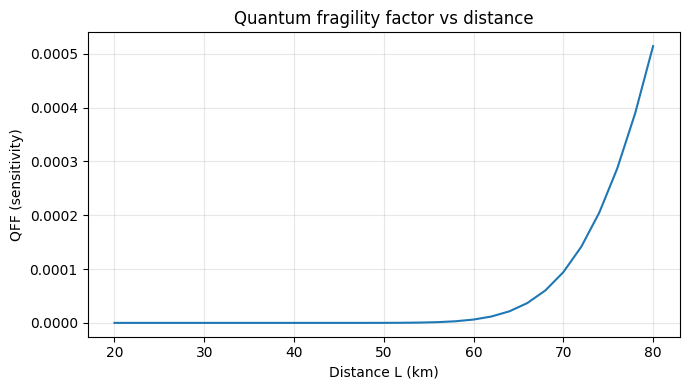

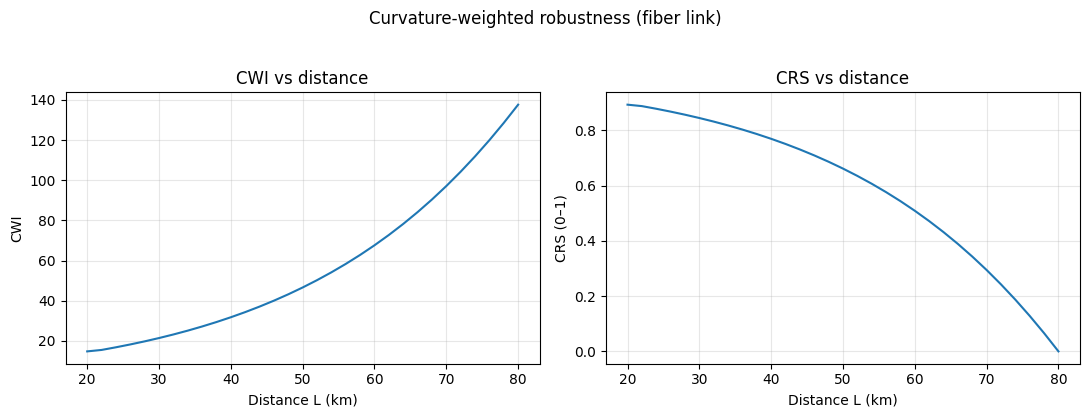


=== Summary table (dfL) ===


,L_km,p_phi,F_mean,DB_mean,GDI_mean,GAC_mean,LB_mean,CWI_mean,CRS_mean,QFF_mean
0,20.0,0.486583,0.635108,0.613420,0.935603,0.999990,0.614796,14.755094,0.892801,2.448548e-10
1,22.0,0.519695,0.635108,0.613420,0.980868,0.999970,0.644723,15.473345,0.887583,2.904949e-10
2,24.0,0.550671,0.635108,0.613420,1.064448,0.999907,0.699750,16.794006,0.877988,1.618007e-10
3,26.0,0.579650,0.635108,0.613420,1.154460,0.999820,0.758998,18.215963,0.867658,4.823767e-10
4,28.0,0.606759,0.635108,0.613420,1.251484,0.999708,0.822846,19.748302,0.856525,2.162619e-10
5,30.0,0.632121,0.635108,0.613420,1.356073,0.999594,0.891656,21.399744,0.844527,1.702213e-10
6,32.0,0.655846,0.635108,0.613420,1.468779,0.999497,0.965791,23.178996,0.831600,5.726529e-10
7,34.0,0.678042,0.635108,0.613420,1.590170,0.999393,1.045624,25.094987,0.817680,7.722879e-10
8,36.0,0.698806,0.635108,0.613420,1.720835,0.999289,1.131543,27.157038,0.802699,1.166289e-09
9,38.0,0.718231,0.635108,0.613420,1.861398,0.999189,1.223957,29.374971,0.786585,7.850017e-10


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm

# ------------------------------------------------------------
# Pauli matrices & identity
# ------------------------------------------------------------
I2 = np.eye(2, dtype=np.complex128)
X  = np.array([[0, 1],[1, 0]], dtype=np.complex128)
Y  = np.array([[0, -1j],[1j, 0]], dtype=np.complex128)
Z  = np.array([[1, 0],[0, -1]], dtype=np.complex128)

# ------------------------------------------------------------
# State utilities & geometric distances
# ------------------------------------------------------------
def pure_to_rho(psi):
    """Return the density matrix rho = |psi><psi|."""
    psi = np.asarray(psi, dtype=np.complex128).reshape(2,1)
    psi /= np.linalg.norm(psi)
    return psi @ psi.conj().T

def haar_random_pure_qubit(n: int, seed: int = 42):
    """Generate n Haar-random pure qubit states."""
    rng = np.random.default_rng(seed)
    out = []
    for _ in range(n):
        z = rng.normal(size=2) + 1j * rng.normal(size=2)
        psi = z / np.linalg.norm(z)
        out.append(pure_to_rho(psi))
    return out

def fidelity(rho, sigma):
    """Uhlmann fidelity F(rho, sigma)."""
    sr = sqrtm(rho)
    inner = sr @ sigma @ sr
    inner = (inner + inner.conj().T) / 2
    root = sqrtm(inner)
    val = np.real(np.trace(root))**2
    return float(np.clip(val, 0, 1))

def bures_distance(rho, sigma):
    """Bures distance."""
    F = fidelity(rho, sigma)
    return float(np.sqrt(max(0, 2*(1 - np.sqrt(F)))))

# ------------------------------------------------------------
# Qubit channels (Kraus representations)
# ------------------------------------------------------------
def apply_kraus(rho, Ks):
    """Apply a set of Kraus operators Ks to state rho."""
    out = sum(K @ rho @ K.conj().T for K in Ks)
    out = (out + out.conj().T) / 2
    tr = np.real(np.trace(out))
    return out / tr if tr != 0 else I2/2

def dephasing_kraus(p):
    """Dephasing channel with parameter p."""
    p = float(np.clip(p, 0, 1))
    return [np.sqrt(1-p)*I2, np.sqrt(p)*Z]

# ------------------------------------------------------------
# Trajectories & geometric metrics
# ------------------------------------------------------------
def trajectory(rho0, Ks, depth):
    """Trajectory rho_0 → rho_1 → ... of depth 'depth'."""
    traj = [rho0]
    rho = rho0
    for _ in range(depth):
        rho = apply_kraus(rho, Ks)
        traj.append(rho)
    return traj

def trajectory_length_bures(traj):
    """Total Bures length L_B of a trajectory."""
    return sum(bures_distance(traj[i], traj[i+1]) for i in range(len(traj)-1))

def gdi(traj):
    """Geodesic deviation index = L_B / D_B."""
    LB = trajectory_length_bures(traj)
    DB = bures_distance(traj[0], traj[-1])
    return float(LB / max(DB, 1e-12))

def gac_mean(traj):
    """Mean local alignment toward the final state (geometric acceleration)."""
    T = traj[-1]
    vals = []
    for i in range(len(traj)-1):
        A, B = traj[i], traj[i+1]
        dAB = bures_distance(A, B)
        dAT = bures_distance(A, T)
        dBT = bures_distance(B, T)
        denom = 2*dAB*max(dAT, 1e-12)
        if denom <= 1e-12:
            continue
        cos_th = (dAB**2 + dAT**2 - dBT**2) / denom
        vals.append(np.clip(cos_th, -1, 1))
    return float(np.mean(vals)) if vals else 1.0

def bures_speeds_and_accel(traj):
    """Return (speed series v_k, acceleration series a_k)."""
    v = [bures_distance(traj[i], traj[i+1]) for i in range(len(traj)-1)]
    a = [abs(v[i+1] - 2*v[i] + v[i-1]) for i in range(1, len(v)-1)] if len(v)>2 else []
    return v, a

# ------------------------------------------------------------
# Numeric quantum fragility factor (QFF)
# ------------------------------------------------------------
def qff_numeric(channel_param_fn, L, dL, depth, states):
    """Central finite-difference estimate of sensitivity wrt distance L."""
    Lm, Lp = L - dL, L + dL
    vals = []
    for rho0 in states:
        p0 = channel_param_fn(L)
        pm = channel_param_fn(Lm)
        pp = channel_param_fn(Lp)
        trajm = trajectory(rho0, dephasing_kraus(pm), depth)
        trajp = trajectory(rho0, dephasing_kraus(pp), depth)
        dB_m = bures_distance(trajm[0], trajm[-1])
        dB_p = bures_distance(trajp[0], trajp[-1])
        vals.append(abs(dB_p - dB_m) / (2*dL))
    return float(np.mean(vals))

# ------------------------------------------------------------
# CWI and curvature-weighted robustness
# ------------------------------------------------------------
R_ABS = 24.0  # |scalar curvature| in the qubit–Bures metric

def cwi_from_traj(traj):
    """Return (CWI, LB)."""
    LB = trajectory_length_bures(traj)
    return float(R_ABS * LB), LB

# ------------------------------------------------------------
# Setup for fiber-link case study
# ------------------------------------------------------------
DEPTH = 32
N_RANDOM = 24
L_MIN, L_MAX, N_L = 20.0, 80.0, 31
L_vals = np.linspace(L_MIN, L_MAX, N_L)

L_phi = 30.0  # coherence length (km)

def p_phi(L):
    """Dephasing probability as function of distance L."""
    return 1 - np.exp(-L / L_phi)

def sample_states(n_random, seed=42):
    """Cardinal + Haar-random states."""
    cardinal = [
        pure_to_rho([1,0]), pure_to_rho([0,1]),
        pure_to_rho([1/np.sqrt(2),  1/np.sqrt(2)]),
        pure_to_rho([1/np.sqrt(2), -1/np.sqrt(2)]),
        pure_to_rho([1/np.sqrt(2),  1j/np.sqrt(2)]),
        pure_to_rho([1/np.sqrt(2), -1j/np.sqrt(2)]),
    ]
    return cardinal + haar_random_pure_qubit(n_random, seed)

STATES = sample_states(N_RANDOM)

# ------------------------------------------------------------
# Sweep vs distance L
# ------------------------------------------------------------
rows = []
for L in L_vals:
    p = p_phi(L)
    Ks = dephasing_kraus(p)
    Fs, DBs, GDIs, GACs, LBs, CWIs = [], [], [], [], [], []
    for rho0 in STATES:
        traj = trajectory(rho0, Ks, DEPTH)
        Fs.append(fidelity(traj[0], traj[-1]))
        DBs.append(bures_distance(traj[0], traj[-1]))
        GDIs.append(gdi(traj))
        GACs.append(gac_mean(traj))
        cwi, LB = cwi_from_traj(traj)
        CWIs.append(cwi); LBs.append(LB)
    rows.append({
        "L_km": L,
        "p_phi": p,
        "F_mean": np.mean(Fs),
        "DB_mean": np.mean(DBs),
        "GDI_mean": np.mean(GDIs),
        "GAC_mean": np.mean(GACs),
        "LB_mean": np.mean(LBs),
        "CWI_mean": np.mean(CWIs),
    })

dfL = pd.DataFrame(rows)

# CRS normalization
CWI_max = dfL["CWI_mean"].max()
dfL["CRS_mean"] = 1 - dfL["CWI_mean"] / CWI_max
dfL["CRS_mean"] = dfL["CRS_mean"].clip(0, 1)

# QFF
dL = (L_MAX - L_MIN)/(N_L - 1)
dfL["QFF_mean"] = [
    qff_numeric(p_phi, L, dL, DEPTH, STATES)
    for L in L_vals
]

print("\n=== Full DataFrame dfL ===")
dfL

# ------------------------------------------------------------
# Figure R1 — F, DB, GDI, GAC vs distance
# ------------------------------------------------------------
d = dfL.sort_values("L_km")
plt.figure(figsize=(9,5))
plt.plot(d["L_km"], d["F_mean"],  label="Fidelity")
plt.plot(d["L_km"], d["DB_mean"], label="Bures distance")
plt.plot(d["L_km"], d["GDI_mean"],label="GDI")
plt.plot(d["L_km"], d["GAC_mean"],label="GAC")
plt.xlabel("Distance L (km)")
plt.ylabel("Index value")
plt.title("Metric trends vs distance (fiber link)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Figure R2 — Local fragility (speeds & acceleration)
# ------------------------------------------------------------
def mean_speeds_accel(L):
    """Return mean speed and acceleration over all states."""
    Ks = dephasing_kraus(p_phi(L))
    v_list, a_list = [], []
    for rho0 in STATES:
        traj = trajectory(rho0, Ks, DEPTH)
        v, a = bures_speeds_and_accel(traj)
        if v: v_list.append(v)
        if a: a_list.append(a)
    max_v = max(map(len, v_list)) if v_list else 0
    max_a = max(map(len, a_list)) if a_list else 0
    V = np.array([vi + [0]*(max_v-len(vi)) for vi in v_list]) if max_v>0 else np.zeros((1,1))
    A = np.array([ai + [0]*(max_a-len(ai)) for ai in a_list]) if max_a>0 else np.zeros((1,1))
    return V.mean(axis=0), A.mean(axis=0)

L_choices = [30, 50, 70]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
for Lc in L_choices:
    v_mean, _ = mean_speeds_accel(Lc)
    plt.plot(range(1,1+len(v_mean)), v_mean, label=f"L={Lc} km")
plt.xlabel("Step")
plt.ylabel("Bures speed")
plt.title("Local Bures speed")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1,2,2)
for Lc in L_choices:
    _, a_mean = mean_speeds_accel(Lc)
    plt.plot(range(2,2+len(a_mean)), a_mean, label=f"L={Lc} km")
plt.xlabel("Step")
plt.ylabel("Bures acceleration")
plt.title("Local Bures acceleration")
plt.grid(alpha=0.3)
plt.legend()

plt.suptitle("Local fragility vs step (fiber link)", y=1.03)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Figure R3 — QFF vs distance
# ------------------------------------------------------------
plt.figure(figsize=(7,4))
plt.plot(d["L_km"], d["QFF_mean"])
plt.xlabel("Distance L (km)")
plt.ylabel("QFF (sensitivity)")
plt.title("Quantum fragility factor vs distance")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Figure R4 — CWI and CRS vs distance
# ------------------------------------------------------------
plt.figure(figsize=(11,4))

plt.subplot(1,2,1)
plt.plot(d["L_km"], d["CWI_mean"])
plt.xlabel("Distance L (km)")
plt.ylabel("CWI")
plt.title("CWI vs distance")
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(d["L_km"], d["CRS_mean"])
plt.xlabel("Distance L (km)")
plt.ylabel("CRS (0–1)")
plt.title("CRS vs distance")
plt.grid(alpha=0.3)

plt.suptitle("Curvature-weighted robustness (fiber link)", y=1.03)
plt.tight_layout()
plt.show()

print("\n=== Summary table (dfL) ===")
dfL
